# Financial Econometrics I

#### High-frequency financial models III - Realized Measures, Heterogeneous Autoregressive Model, Realized GARCH

by František Čech

#### Seminar 9: Summer Semester 2025/2026

In [1]:
library(rugarch)
library(repr)
options(repr.plot.width = 7, repr.plot.height = 4)
library(xts)
library(highfrequency)

Loading required package: parallel

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




## Jump diffusion model with stochastic volatility

Simulate model of stochastic volatility defined as

$$d X(t) = \left(\mu - \frac{\sigma^2(t)}{2}\right) dt + \sigma (t) d W_1(t) + c(t) d N(t)$$ 
$$d \sigma^2 (t) = \mathcal{K} (\alpha - \sigma^2(t)) dt + \gamma \sigma (t) d W_2 (t)$$
  
  $W_1 (t)$ and $W_2 (t)$ will be correlated Brownian motions.

In [2]:
start_date<-as.Date("2010-01-01")
end_date<-as.Date(Sys.time()) # today
days<-seq(from=start_date,to=end_date,by ="day")
biz_days<-as.POSIXlt(days)$wday
biz_days[biz_days==6|biz_days==0]<- NA
biz_days<-as.Date(na.omit(cbind(days,biz_days))[,1],origin="1970-01-01")

time_sim<- seq(from=as.POSIXct(paste(start_date,"9:00")),to=as.POSIXct(paste(start_date, "15:59")),by="min")
hh_mm<- format(time_sim, format = "%H:%M:%S")

TT = 500
NN = 60 * 7
dt <- 1 / NN / 252
date_time<-unlist(lapply(1:TT, function(x) paste(rep(biz_days[x],NN),hh_mm)))
                         
mu <- 0.05
kk <- 5
a <- 0.04
g <- 0.5
rho <- -0.5
                         
W1 <- rnorm(TT * NN)
z <- rnorm(TT * NN)
W2 <- rho * W1 + sqrt(1 - rho^2) * z
J <- rnorm(TT * NN) * rpois(TT * NN, 2 / NN)
                         
                         
ret <- vector()
rettrue <- vector()
ret[1] <- 0
rettrue[1] <- 0
sigmasqr <- rchisq(1, (4 * kk * a) / g^2) / ((4 * kk) / g^2)
                         
for (t in 2:(TT * NN)){
      ret[t] <- (mu - sigmasqr / 2) * dt + sqrt(sigmasqr * dt) * W2[t - 1] + J[t - 1] * sqrt(dt)
  rettrue[t] <- (mu - sigmasqr / 2) * dt + sqrt(sigmasqr * dt) * W2[t - 1]
  sigmasqr <- max(0, sigmasqr + kk * (a - sigmasqr) * dt + g * sqrt(sigmasqr * dt) * W1[t - 1])
}

ret_xts<-xts(x=ret,order.by = strptime(date_time, "%Y-%m-%d %H:%M"))
rettrue_xts<-xts(x=rettrue,order.by = strptime(date_time, "%Y-%m-%d %H:%M"))

daily <- unlist(lapply(lapply(1:TT, function (t){return(ret_xts[((t - 1) * NN + 1):(t * NN)])}), sum))
daily_xts<-xts(x=daily,order.by =unique(as.Date(index(ret_xts))))
dailytrue <- unlist(lapply(lapply(1:TT, function (t){return(rettrue_xts[((t - 1) * NN + 1):(t * NN)])}), sum))
dailytrue_xts<-xts(x=dailytrue,order.by =unique(as.Date(index(rettrue_xts))))    
                         
RV_HF<-rCov(rData=ret_xts,cor=FALSE,align.by = NULL,makeReturns = FALSE)
index(RV_HF)<-as.Date(index(RV_HF))                        

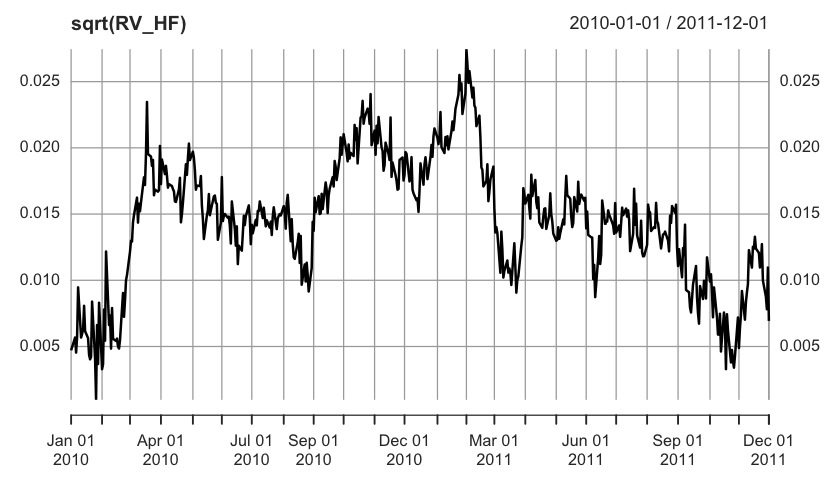

In [3]:
plot(sqrt(RV_HF))

### Bipower Variation

We will use Bipower Variation introduced in Barndorff-Nielsen and Shephard (2004) to estimate integrated volatility. Formulation of BPV ensures its robustness to jumps:

$$BPV_t = \frac{\pi}{2} \sum_{j = 2}^{m} \lvert r_{j-1} \rvert \lvert r_j \rvert,$$

where m is number of returns observations for day t.

In [5]:
BPV_HF<-rBPCov(rData=ret_xts)
index(BPV_HF)<-as.Date(index(BPV_HF))
j_HF<-RV_HF-BPV_HF

jumps_test<- BNSjumpTest(ret_xts,IVestimator = "BV",IQestimator = "TP")

I_HF <- sapply(1:TT, function (j) 
{if (jumps_test[j,"p.value"] < 0.05){1}
  else {0}})
J_HF <- j_HF * I_HF

### Bipower Variation - noise robust
introduced by Andersen et al (2011) (https://doi.org/10.1016/j.jeconom.2010.03.029)

$$BPV(Andersen)_t = \frac{\frac{m}{m-2}}{(2 / \pi)} \sum_{j = 3}^{m} \lvert r_{j-2} \rvert \lvert r_j \rvert,$$

where m is number of returns observations for day t.

In [6]:
C <- (NN / (NN - 2)) / (2 / pi)
BPV_A <- unlist(lapply(lapply(1:TT, function (t){
  return(abs(as.numeric(ret_xts[((t - 1) * NN + 1):(t * NN - 2)])) * abs(as.numeric(ret_xts[((t - 1) * NN + 3):(t * NN)])))}), sum))
BPV_A <- BPV_A * C
BPV_A_xts<-xts(x=BPV_A,order.by =unique(as.Date(index(ret_xts))))

### Jumps - detection
Similar to work of Andersen et al (2011), we will use Z statistic to distinguish true jumps from deviations caused by sampling noise. First, compute the estimate of fourth moment

$$TQ_t = \frac{\frac{m^2}{m-4}}{(0.8313)^3} \sum_{j = 5}^m \lvert r_{j-4} \rvert^{4 / 3} \rvert r_{j-3} \rvert^{4 / 3} \rvert r_{j-2} \rvert^{4 / 3}$$ 

In [7]:
L <- (NN^2) / (0.8313^3 * (NN - 4))
TQ <- unlist(lapply(lapply(1:TT, function (t){
  return(abs(as.numeric(ret_xts[((t - 1) * NN + 1):(t * NN - 4)]))^(4 / 3) * 
         abs(as.numeric(ret_xts[((t - 1) * NN + 2):(t * NN - 3)]))^(4 / 3) * 
         abs(as.numeric(ret_xts[((t - 1) * NN + 3):(t * NN - 2)]))^(4 / 3))}), sum))
TQ <- TQ * L
TQ_xts<-xts(x=TQ,order.by =unique(as.Date(index(ret_xts))))

Now, the Z statistic is formalized as

$$Z_t = \frac{\frac{RV_t - BPV_t}{RV_t}}{\sqrt{(((\pi / 2)^2 + \pi - 5) / m) * max(1, TQ_t / BPV_t)}},$$

where $max(1, TQ_t / BPV_t)$ is the small sample refinement of the fourth moment.

Hence, jump variation for day t will be

$$JV_t = I_{Z_t > \Phi (\alpha)} (RV_t - BPV_t),$$

where $\Phi (\alpha)$ is a critical value from $N(0, 1)$ distribution.

In [8]:
j <- RV_HF - BPV_A_xts
Z <- (j / RV_HF) / sqrt((((pi / 2)^2 + pi - 5) / NN) * unlist(lapply(1:TT, function (i) 
{max(1, TQ_xts[i] / BPV_A_xts[i]^2)})))

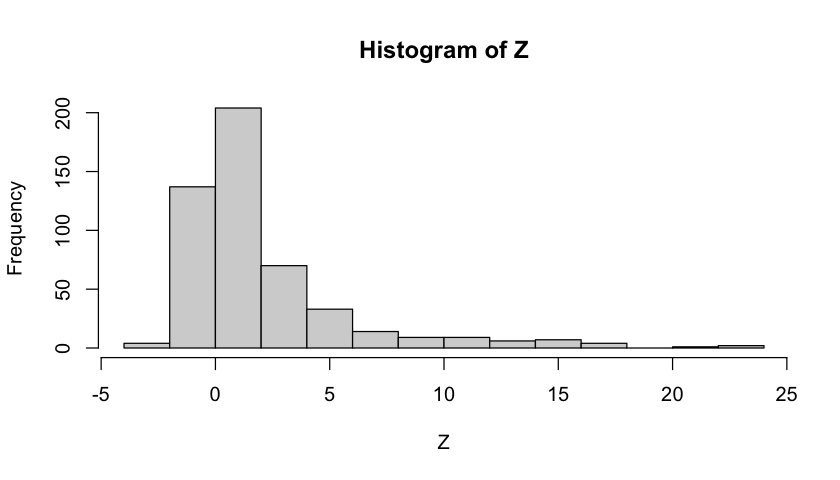

In [9]:
hist(Z)

In [10]:
proc <- 5
I5 <- sapply(1:TT, function (j) 
{if (Z[j] > qnorm(1 - (proc / (2 * 100)), lower.tail = TRUE)) {1}
  else {0}})
sum(I5)
J5 <- j * I5

[1] 157

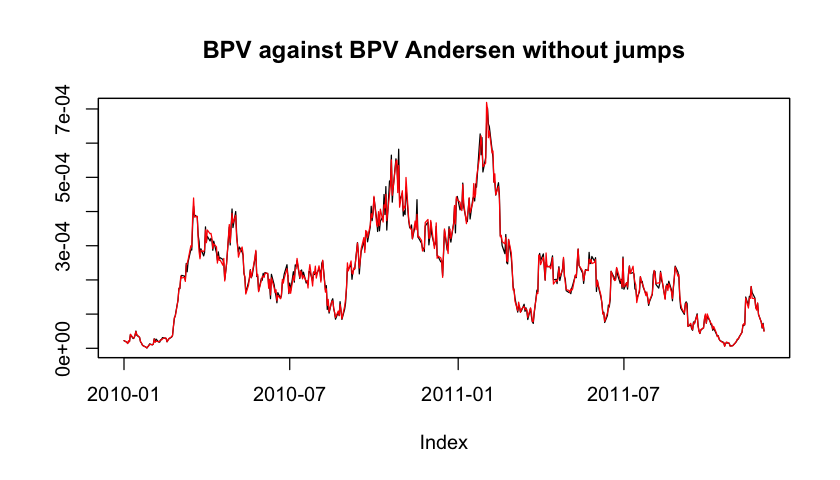

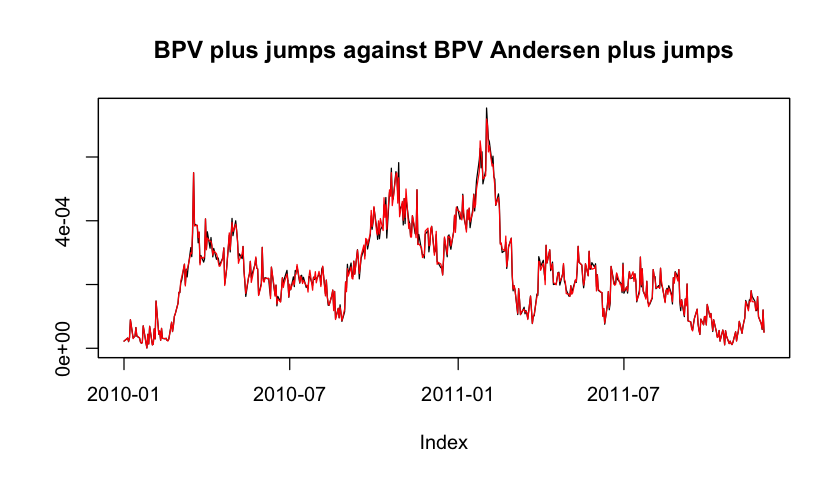

In [11]:
plot.zoo(BPV_HF, ylab = NA, main = 'BPV against BPV Andersen without jumps')
lines(zoo(BPV_A_xts), col = 'red', lwd = 1)

plot.zoo(BPV_HF + J_HF, ylab = NA, main = 'BPV plus jumps against BPV Andersen plus jumps')
lines(zoo(BPV_A_xts + J5), col = 'red', lwd = 1)

### MedRV estimator of Andersen et al. (2012) - jump and noise robust
$$MedRV_t = \frac{\pi}{6-4\sqrt{3}+\pi}\frac{m}{m-2} \sum_{j = 2}^{m-1}med(\lvert r_{j-1} \rvert, \lvert r_j \rvert, \lvert r_{j+1} \rvert)^2,$$

In [12]:
medRV_HF<-rMedRVar(rData=ret_xts)
index(medRV_HF)<-as.Date(index(medRV_HF))

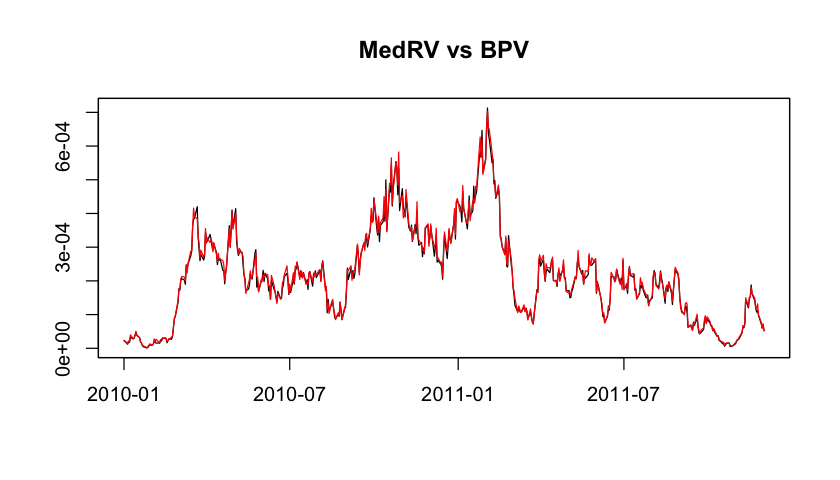

In [13]:
plot.zoo(medRV_HF, xlab=NA, ylab=NA,main="MedRV vs BPV")
lines(zoo(BPV_HF),col="red")

In [14]:
# jumps
j_medRV_HF<-RV_HF-medRV_HF
jumps_test_medRV<- BNSjumpTest(ret_xts,IVestimator = "rMedRVar",IQestimator = "rMedRQuar") # jumps significance

I_medRV_HF <- sapply(1:TT, function (j) 
{if (jumps_test_medRV[j,"p.value"] < 0.05){1}
  else {0}})
J_medRV_HF <- j_medRV_HF * I_medRV_HF

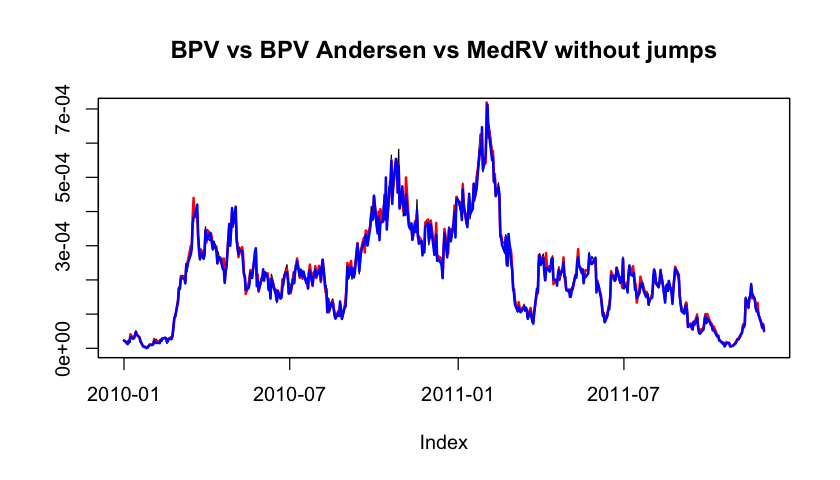

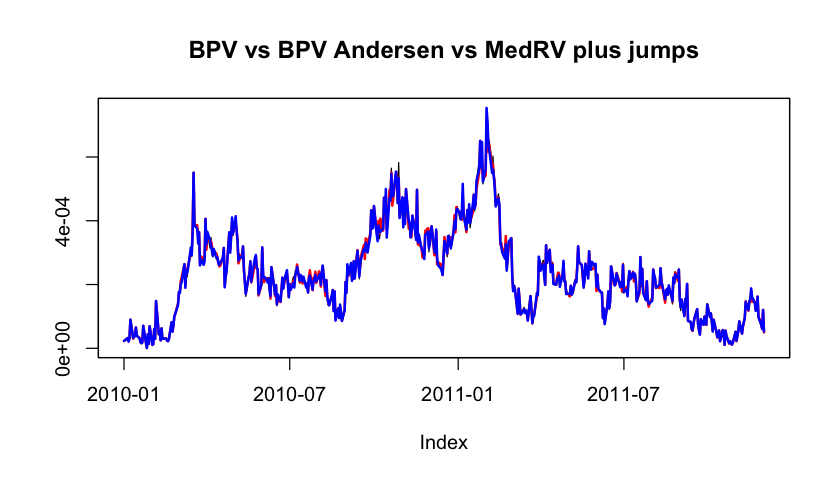

In [15]:
plot.zoo(BPV_HF, ylab = NA, main = 'BPV vs BPV Andersen vs MedRV without jumps')
lines(zoo(BPV_A_xts), col = 'red', lwd = 2)
lines(zoo(medRV_HF), col = 'blue', lwd = 2)

plot.zoo(BPV_HF + J_HF, ylab = NA, main = 'BPV vs BPV Andersen vs MedRV plus jumps')
lines(zoo(BPV_A_xts + J5), col = 'red', lwd = 2)
lines(zoo(medRV_HF + J_medRV_HF), col = 'blue', lwd = 2)

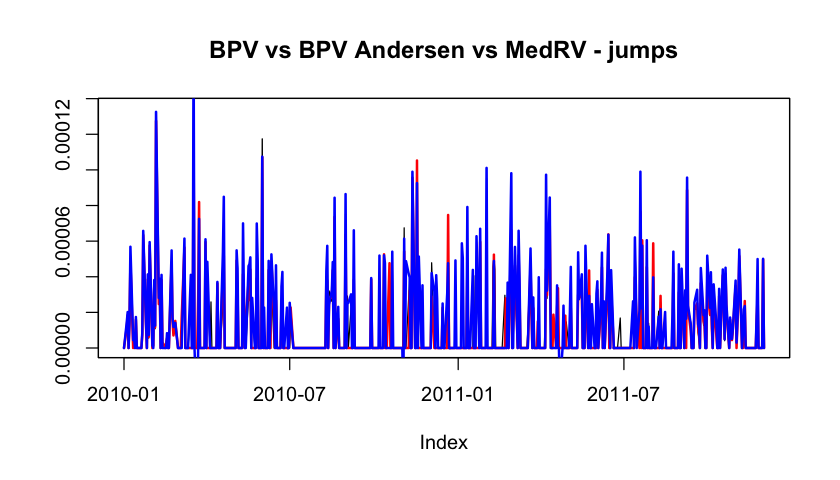

In [16]:
plot.zoo(J_HF, ylab = NA, main = 'BPV vs BPV Andersen vs MedRV - jumps')
lines(zoo(J5), col = 'red', lwd = 2)
lines(zoo(J_medRV_HF), col = 'blue', lwd = 2)

## How to model Realized Measures? 
## Heterogeneous Autoregressive Model
HAR model has form (https://doi.org/10.1093/jjfinec/nbp001)

$$\sqrt{RV_t} = \alpha + \beta_1 \sqrt{RV_{t-1}} + \beta_2 \sqrt{RV_{t-1}^{(5)}} + \beta_3 \sqrt{RV_{t-1}^{(22)}} + u_t,$$

where $RV_t^{(h)} = (1 / h) \sum_{i = 0}^{h - 1} RV_{t-i}$.

First step $\Rightarrow$ prepare the data.

In [17]:
RV5 <- unlist(lapply(lapply(1:(TT - 4), function (t) {return(RV_HF[t:(t + 4)])}), mean))
RV22 <- unlist(lapply(lapply(1:(TT - 21), function (t) {return(RV_HF[t:(t + 21)])}), mean))

RVol <- sqrt(RV_HF)
RVol5 <- sqrt(RV5)
RVol22 <- sqrt(RV22)

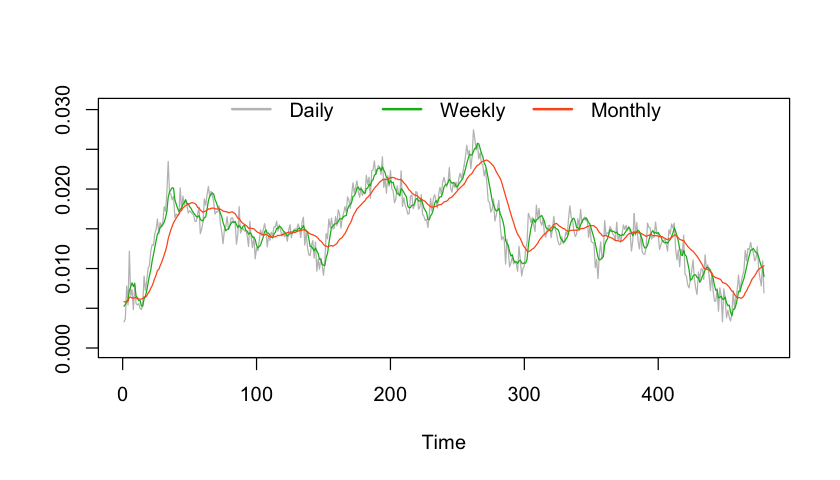

In [18]:
T5 <- length(RVol5)
T22 <- length(RVol22)

plot.ts(RVol[22:TT], ylab = NA, col = 'gray75', ylim = c(0, max(RVol) * 1.1))
lines(RVol5[18:T5], col = '#03B719')
lines(RVol22, col = '#FF591B')
legend("top", ncol = 3, legend = c('Daily', 'Weekly', 'Monthly'),
       col = c('gray75', '#03B719', '#FF591B'), lwd = 2, bty = 'n')

Now estimate 

$$\sqrt{RV_t} = \alpha + \beta_1 \sqrt{RV_{t-1}} + \beta_2 \sqrt{RV_{t-1}^{(5)}} + \beta_3 \sqrt{RV_{t-1}^{(22)}} + u_t.$$

In [19]:
HAR <- lm(RVol[23:TT] ~ RVol[22:(TT - 1)] + RVol5[18:(T5 - 1)] + RVol22[1:(T22 - 1)])
summary(HAR)


Call:
lm(formula = RVol[23:TT] ~ RVol[22:(TT - 1)] + RVol5[18:(T5 - 
    1)] + RVol22[1:(T22 - 1)])

Residuals:
       Min         1Q     Median         3Q        Max 
-0.0040548 -0.0009563 -0.0000547  0.0009704  0.0059967 

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)          0.0007414  0.0002657   2.790  0.00548 ** 
RVol[22:(TT - 1)]    0.5306916  0.0557150   9.525  < 2e-16 ***
RVol5[18:(T5 - 1)]   0.4963083  0.0727027   6.827 2.67e-11 ***
RVol22[1:(T22 - 1)] -0.0773482  0.0383083  -2.019  0.04404 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.001521 on 474 degrees of freedom
Multiple R-squared:  0.8854,	Adjusted R-squared:  0.8847 
F-statistic:  1221 on 3 and 474 DF,  p-value: < 2.2e-16


In [20]:
library(sandwich)
NW           <- NeweyWest(HAR,lag=22)
robust_se    <- sqrt(diag(NW))
robust_se

(Intercept)   RVol[22:(TT - 1)]  RVol5[18:(T5 - 1)] RVol22[1:(T22 - 1)] 
       0.0003114235        0.0578174523        0.0722401070        0.0393670603

compare to GARCH

In [21]:
garchspecm1 <- ugarchspec(variance.model=list(model = "sGARCH", garchOrder = c(1, 1)),
    mean.model = list(armaOrder=c(0, 0), include.mean=TRUE, archm = TRUE, archpow = 1))
                         
garchvolm1 <- ugarchfit(garchspecm1, daily_xts)

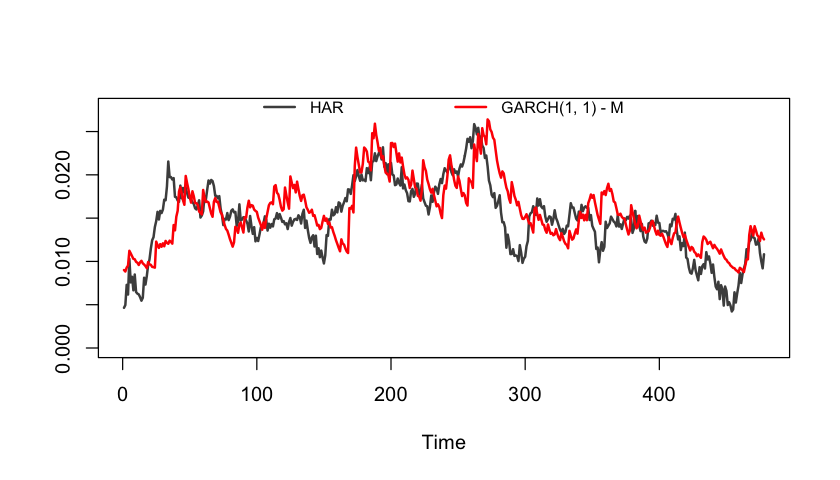

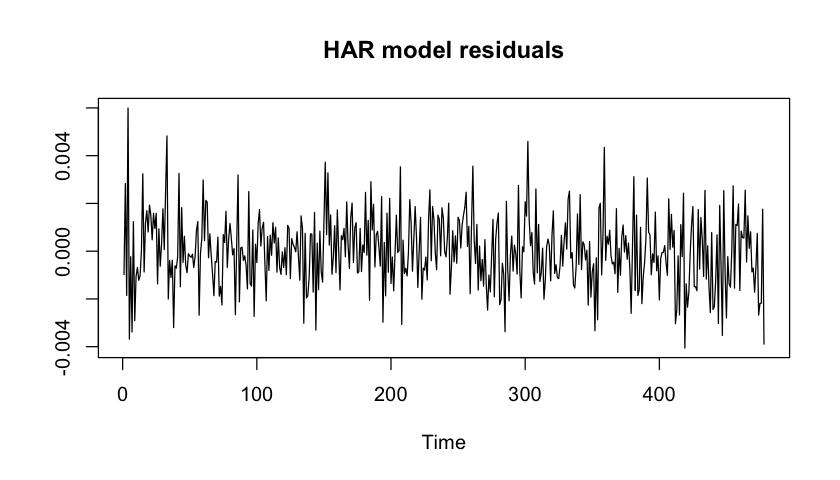

In [22]:
plot.ts(HAR$fitted.values, ylab = NA, lwd = 2, col = 'gray30', 
        ylim = c(0, 1.05 * max(max(HAR$fitted.values), max(garchvolm1@fit$sigma))))
lines(garchvolm1@fit$sigma[23:TT], col = 'red', lwd = 2)
legend("top", ncol = 2, legend = c('HAR', 'GARCH(1, 1) - M'), col = c('gray30', 'red'), 
       lwd = 2, bty = 'n', cex = 0.8)

plot.ts(HAR$residuals, ylab = NA, main = 'HAR model residuals')

What about residuals? Is the model valid? We can see heteroscedasticity in residuals pointing us to volatility of volatility... can be modelled by adding GARCH structure, i.e. https://www.tandfonline.com/doi/full/10.1080/07474930701853616

HAR from highfrequency package (https://cran.r-project.org/web/packages/highfrequency/highfrequency.pdf)

In [23]:
HAR_HF<- HARmodel(data = sqrt(RV_HF) , periods = c(1,5,22), RVest = c("rCov"),
type = "HAR", h = 1, transform = NULL, inputType = "RM")

In [24]:
HAR_HF


Model:
RV1 = beta0  +  beta1 * RV1 +  beta2 * RV5 +  beta3 * RV22

Coefficients:
     beta0       beta1       beta2       beta3  
 0.0008064   0.5261552   0.4990356  -0.0788352  
Newey-West Standard Errors:
    beta0      beta1      beta2      beta3  
0.0003006  0.0584315  0.0736281  0.0387383  


    r.squared  adj.r.squared  
       0.8858         0.8850  


In [25]:
HAR_HF<- HARmodel(data = RV_HF , periods = c(1,5,22), RVest = c("rCov"),
type = "HAR", h = 1, transform = "sqrt", inputType = "RM")

HAR_HF
round(coef(HAR),7)
round(robust_se,7)


Model:
sqrt(RV1) = beta0  +  beta1 * sqrt(RV1) +  beta2 * sqrt(RV5) +  beta3 * sqrt(RV22)

Coefficients:
     beta0       beta1       beta2       beta3  
 0.0007414   0.5306916   0.4963083  -0.0773482  
Newey-West Standard Errors:
    beta0      beta1      beta2      beta3  
0.0003114  0.0578175  0.0722401  0.0393671  


    r.squared  adj.r.squared  
       0.8854         0.8847  


(Intercept)   RVol[22:(TT - 1)]  RVol5[18:(T5 - 1)] RVol22[1:(T22 - 1)] 
          0.0007414           0.5306916           0.4963083          -0.0773482

(Intercept)   RVol[22:(TT - 1)]  RVol5[18:(T5 - 1)] RVol22[1:(T22 - 1)] 
          0.0003114           0.0578175           0.0722401           0.0393671

In [26]:
HAR_HF<- HARmodel(data = RV_HF , periods = c(1,5,22), RVest = c("rCov"),
type = "HAR", h = 1, transform = NULL, inputType = "RM")

HAR_HF


Model:
RV1 = beta0  +  beta1 * RV1 +  beta2 * RV5 +  beta3 * RV22

Coefficients:
     beta0       beta1       beta2       beta3  
 1.289e-05   5.362e-01   4.948e-01  -8.397e-02  
Newey-West Standard Errors:
    beta0      beta1      beta2      beta3  
5.105e-06  6.037e-02  7.255e-02  3.814e-02  


    r.squared  adj.r.squared  
       0.8849         0.8842  


### HAR with jumps
Decompose RV to BPV, and jumps and model/forecast Realized volatility using 

$$\sqrt{RV_t} = \alpha + \beta_1 \sqrt{J_{t-1}} + \beta_2 \sqrt{BPV_{t-1}} + \beta_3 \sqrt{BPV_{t-1}^{(5)}} + \beta_4 \sqrt{BPV_{t-1}^{(22)}} + u_t.$$

### Realized GARCH
* joint modeling of returns and realized measures of volatility
* key feature is a measurement equation that relates the realized measure to the conditional variance of returns

Equations:

$
\begin{align}
r_t= & \sqrt{h_t}z_t \\
ln(h_t)= & \omega + \beta ln(h_{t-1})+\gamma ln(RV_{t-1})\\
ln(RV_t)= & \xi+ \varphi ln(h_t) + u_t
\end{align}
$

details of the estimation can be found here https://cran.r-project.org/web/packages/rugarch/vignettes/Introduction_to_the_rugarch_package.pdf

In [27]:
real_garchspec<- ugarchspec(variance.model = list(model = 'realGARCH', garchOrder = c(1, 1)),
    mean.model = list(armaOrder=c(0, 0), include.mean=TRUE))
real_garch_fit<- ugarchfit(real_garchspec, daily_xts, solver = 'hybrid', realizedVol = sqrt(RV_HF))                         

In [28]:
real_garch_fit


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: realGARCH(1,1)
Mean Model	: ARFIMA(0,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu     -0.000160    0.000535 -0.30017 0.764046
omega   0.201552    0.242002  0.83286 0.404927
alpha1  1.000000    0.093368 10.71028 0.000000
beta1   0.510053    0.041831 12.19324 0.000000
eta11  -0.014587    0.008741 -1.66889 0.095139
eta21   0.036928    0.005503  6.71070 0.000000
delta   0.479735    0.024691 19.42965 0.000000
lambda  0.168430    0.005528 30.47005 0.000000
xi     -0.286416    0.213485 -1.34162 0.179719

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu     -0.000160    0.000520 -0.30862 0.757613
omega   0.201552    0.178182  1.13116 0.257988
alpha1  1.000000    0.195635  5.11155 0.000000
beta1

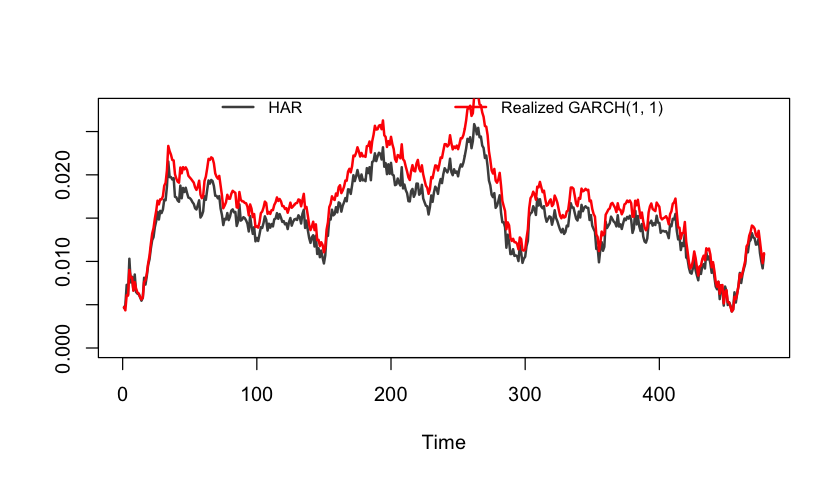

In [29]:
plot.ts(HAR$fitted.values, ylab = NA, lwd = 2, col = 'gray30', 
        ylim = c(0, 1.05 * max(max(HAR$fitted.values), max(garchvolm1@fit$sigma))))
lines(real_garch_fit@fit$sigma[23:TT], col = 'red', lwd = 2)
legend("top", ncol = 2, legend = c('HAR', 'Realized GARCH(1, 1)'), col = c('gray30', 'red'), 
       lwd = 2, bty = 'n', cex = 0.8)

#### Real Data

In [30]:
library(fst)

In [31]:
sample_data<-read.fst(path = "sample_data.fst")
sample_data_xts<-xts(sample_data$V2,order.by = sample_data$V1)["2010/2014"]
rm(sample_data)

In [32]:
head(sample_data_xts)
tail(sample_data_xts)

Warning message:
“object timezone ('UTC') is different from system timezone ('')
  NOTE: set 'options(xts_check_TZ = FALSE)' to disable this warning
    This note is displayed once per session”


                       [,1]
2010-01-04 07:00:00 26.8776
2010-01-04 07:02:00 26.9663
2010-01-04 07:06:00 26.9663
2010-01-04 07:07:00 26.9675
2010-01-04 07:09:00 26.9675
2010-01-04 07:17:00 26.9675

Warning message:
“object timezone ('UTC') is different from system timezone ('')”


                       [,1]
2014-12-31 19:54:00 103.658
2014-12-31 19:55:00 103.649
2014-12-31 19:56:00 103.639
2014-12-31 19:57:00 103.686
2014-12-31 19:58:00 103.602
2014-12-31 19:59:00 103.602

In [33]:
# create 5 min data
index(sample_data_xts)<-index(sample_data_xts)-1
sample_data_xts<-aggregateTS(sample_data_xts,alignBy = "minutes",alignPeriod = 5,dropna = TRUE)
head(sample_data_xts)

Warning message:
“object timezone ('UTC') is different from system timezone ('')”


                          x
2010-01-04 07:00:00 26.8776
2010-01-04 07:05:00 26.9663
2010-01-04 07:10:00 26.9675
2010-01-04 07:20:00 26.9675
2010-01-04 07:30:00 26.9473
2010-01-04 07:35:00 26.9549

In [34]:
RV_sample_data<-rCov(rData = sample_data_xts,makeReturns = TRUE)
index(RV_sample_data)<-as.Date(index(RV_sample_data))

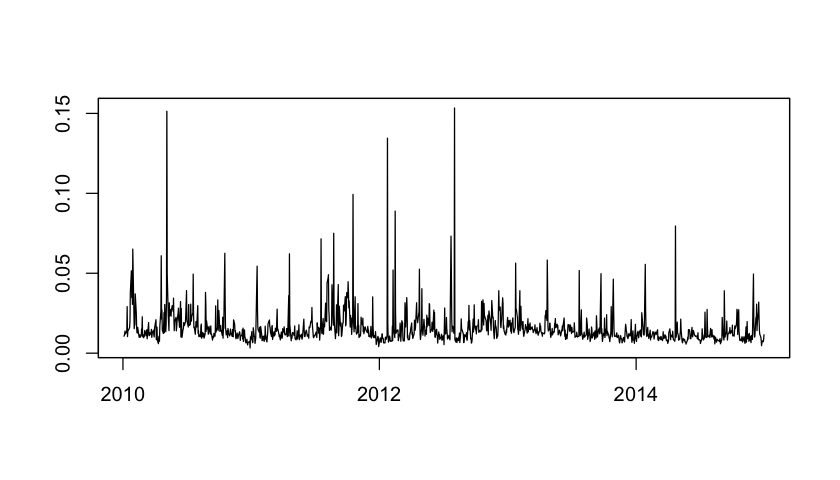

In [35]:
plot.zoo(sqrt(RV_sample_data),xlab=NA,ylab=NA)

In [36]:
HAR_sample_data<-HARmodel(data = RV_sample_data , periods = c(1,5,22), RVest = c("rCov"),
type = "HAR", h = 1, transform = "sqrt",  inputType = "RM")
HAR_sample_data


Model:
sqrt(RV1) = beta0  +  beta1 * sqrt(RV1) +  beta2 * sqrt(RV5) +  beta3 * sqrt(RV22)

Coefficients:
   beta0     beta1     beta2     beta3  
0.009033  0.233263  0.011370  0.156233  
Newey-West Standard Errors:
   beta0     beta1     beta2     beta3  
0.001446  0.038474  0.043149  0.064536  


    r.squared  adj.r.squared  
      0.08076        0.07852  


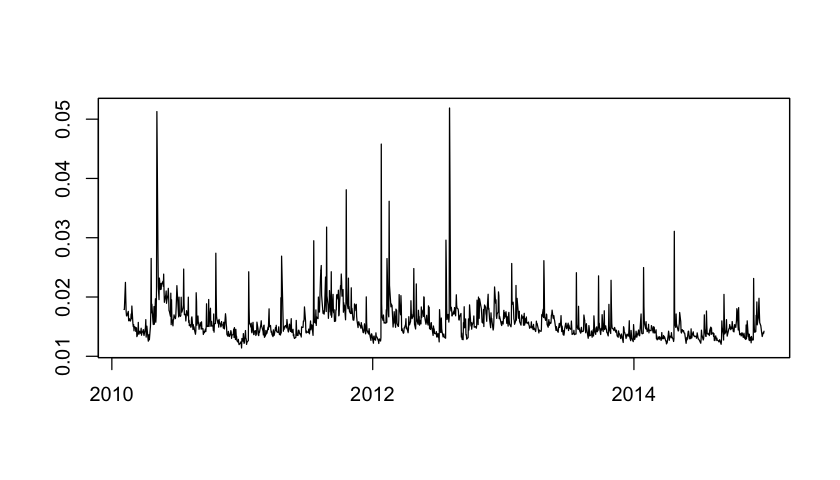

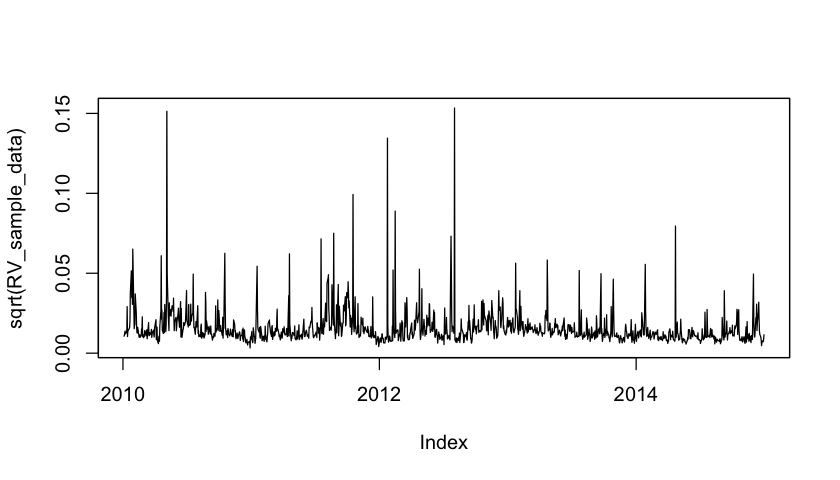

In [37]:
HAR_fitted<-xts(HAR_sample_data$fitted.values,order.by = index(RV_sample_data[23:length(index(RV_sample_data))]))
plot.zoo(HAR_fitted,xlab=NA,ylab=NA)
plot.zoo(sqrt(RV_sample_data))

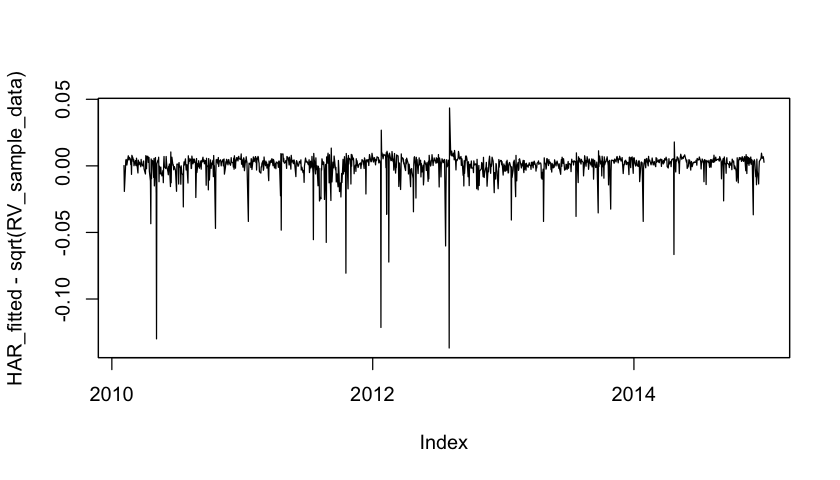

In [38]:
plot.zoo(HAR_fitted-sqrt(RV_sample_data))

In [39]:
sample_data_ret<-log(to.daily(sample_data_xts)[,4]/to.daily(sample_data_xts)[,1])

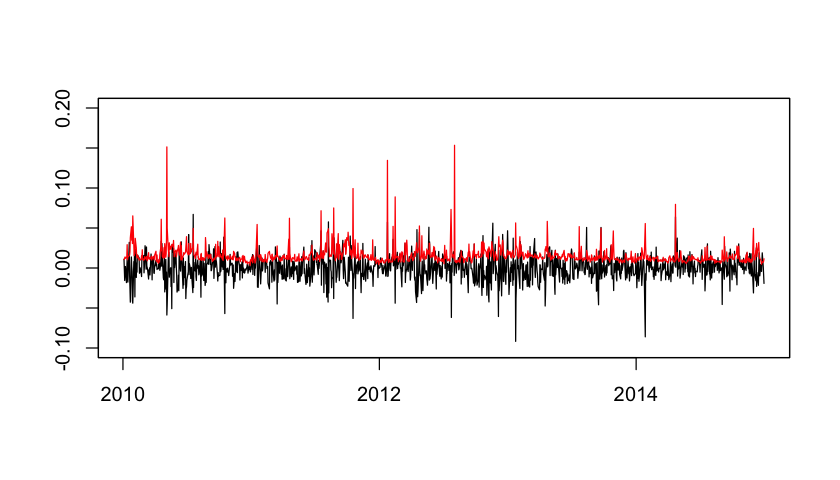

In [40]:
plot.zoo(sample_data_ret,xlab=NA , ylab=NA,ylim=c(-0.1,0.2))
lines(zoo(sqrt(RV_sample_data)),col="red")

In [41]:
real_garchspec<- ugarchspec(variance.model = list(model = 'realGARCH', garchOrder = c(1, 1)),
    mean.model = list(armaOrder=c(0, 0), include.mean=TRUE))
real_garch_sample_data_fit<- ugarchfit(real_garchspec, sample_data_ret, solver = 'hybrid', realizedVol = sqrt(RV_sample_data))                         

garchspec<- ugarchspec(variance.model = list(model = 'sGARCH', garchOrder = c(1, 1)),
    mean.model = list(armaOrder=c(0, 0), include.mean=TRUE))
garch_sample_data_fit<- ugarchfit(garchspec, sample_data_ret)                         

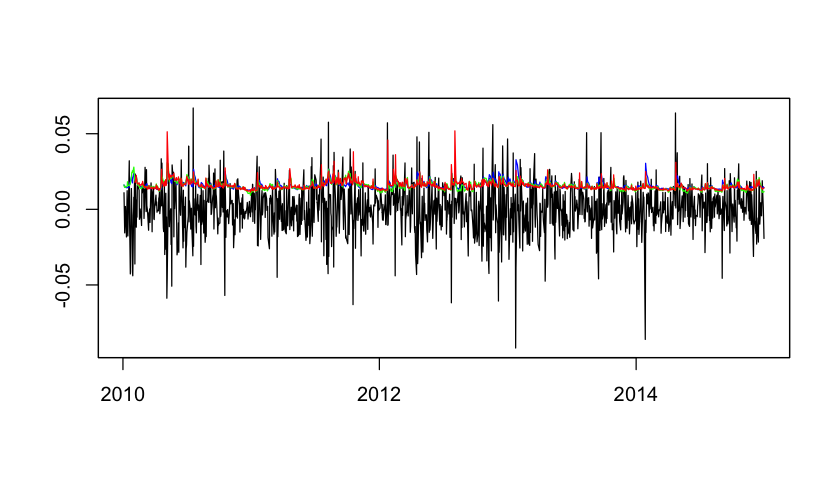

In [42]:
plot.zoo(sample_data_ret,xlab=NA,ylab=NA)
lines(zoo(sigma(garch_sample_data_fit)),col="blue")
lines(zoo(sigma(real_garch_sample_data_fit)),col="green")
lines(zoo(HAR_fitted),col="red")

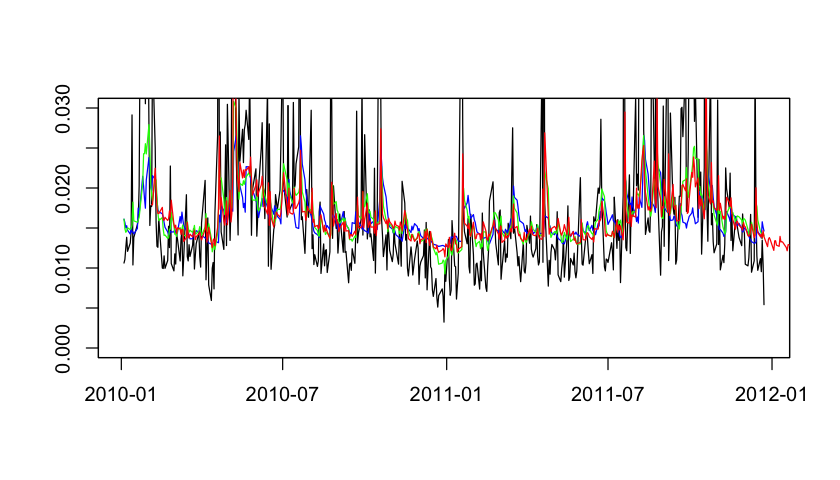

In [43]:
plot.zoo(sqrt(RV_sample_data[1:500,]),xlab=NA,ylab=NA,ylim=c(0,0.03))
lines(zoo(sigma(garch_sample_data_fit))[1:500,],col="blue")
lines(zoo(sigma(real_garch_sample_data_fit))[1:500,],col="green")
lines(zoo(HAR_fitted)[1:500,],col="red")